# Telco Customer Churn — Data Cleaning & Analysis

**Project:** Customer & Revenue Analytics Dashboard  
**Author:** Omar Quinn

This notebook cleans the raw Telco dataset, engineers a handful of business-ready
columns, and produces the KPIs and segment tables that feed the Power BI dashboard.
The framing is deliberately **revenue-first**: churn is measured as lost recurring
revenue, not just a customer count.

## 1. Imports & display settings

In [1]:
# Core data tools
import os
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

# Make tables and charts read cleanly throughout the notebook
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

ACCENT = "#c0392b"   # single accent colour reused for "at-risk" visuals

## 2. Load the raw dataset

In [2]:
# The raw file lives in data/raw/ and is never modified in place.
# All cleaned output is written separately to data/cleaned/.
RAW_PATH     = "data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
CLEANED_PATH = "data/cleaned/telco_churn_cleaned.csv"

df = pd.read_csv(RAW_PATH)
print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns")
df.head()

Loaded 7,043 rows and 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Clean column names

In [3]:
# The Kaggle Telco headers are already well-formed (no spaces, consistent casing),
# so the only real risk is stray leading/trailing whitespace. Stripping it
# guarantees predictable column references everywhere downstream.
df.columns = df.columns.str.strip()
print(list(df.columns))

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


## 4. Convert TotalCharges to numeric

In [4]:
# TotalCharges loads as text because a small number of rows contain a blank
# space instead of a value. Coercing to numeric turns those blanks into NaN,
# which we handle explicitly in the next step.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Blank TotalCharges values converted to NaN:", int(df["TotalCharges"].isna().sum()))

Blank TotalCharges values converted to NaN: 11


## 5. Handle missing values

In [5]:
# First, see exactly where the gaps are.
missing = df.isna().sum()
print(missing[missing > 0])

# The only missing values are TotalCharges for customers with tenure = 0 —
# brand-new accounts that have not completed a billing cycle yet. We fill these
# with 0 (no charges accrued) rather than dropping the rows, so every customer
# is kept in the analysis.
print("\nTenure of rows with missing TotalCharges:",
      df.loc[df["TotalCharges"].isna(), "tenure"].unique())

df["TotalCharges"] = df["TotalCharges"].fillna(0)
print("Remaining missing values in dataset:", int(df.isna().sum().sum()))

TotalCharges    11
dtype: int64

Tenure of rows with missing TotalCharges: [0]
Remaining missing values in dataset: 0


## 6. Create `Churn_Flag`

In [6]:
# Numeric 1/0 version of Churn. A numeric flag lets us treat churn rate as a
# simple average and aggregate revenue with arithmetic.
df["Churn_Flag"] = df["Churn"].map({"Yes": 1, "No": 0}).astype(int)
df[["Churn", "Churn_Flag"]].head()

,Churn,Churn_Flag
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


## 7. Create `Revenue_At_Risk`

In [7]:
# Monthly recurring revenue that leaves the business when a customer churns.
# Active customers contribute 0; churned customers contribute their MonthlyCharges.
# Summing this column gives the total monthly revenue lost to churn — the metric
# that turns a churn count into a dollar figure leadership cares about.
df["Revenue_At_Risk"] = df["MonthlyCharges"] * df["Churn_Flag"]
df[["MonthlyCharges", "Churn_Flag", "Revenue_At_Risk"]].head()

,MonthlyCharges,Churn_Flag,Revenue_At_Risk
0,29.85,0,0.00
1,56.95,0,0.00
2,53.85,1,53.85
3,42.30,0,0.00
4,70.70,1,70.70


## 8. Create `Tenure_Group`

In [8]:
# Bucket tenure (months) into lifecycle stages so retention can be compared
# across the customer journey instead of by raw month number.
bins   = [-1, 12, 24, 48, np.inf]
labels = ["0-12 Months", "13-24 Months", "25-48 Months", "49+ Months"]
df["Tenure_Group"] = pd.cut(df["tenure"], bins=bins, labels=labels)
df["Tenure_Group"].value_counts().sort_index()

Tenure_Group
0-12 Months     2186
13-24 Months    1024
25-48 Months    1594
49+ Months      2239
Name: count, dtype: int64

## 9. Create `Customer_Value_Segment` (based on MonthlyCharges)

In [9]:
# Segment customers by spend using tertiles of MonthlyCharges, giving three
# balanced groups. MonthlyCharges is a clean, intuitive proxy for how much
# revenue a customer contributes each month. (Thresholds can be swapped for
# business-defined price tiers if the company prefers fixed bands.)
df["Customer_Value_Segment"] = pd.qcut(
    df["MonthlyCharges"], q=3, labels=["Low Value", "Medium Value", "High Value"]
)
df.groupby("Customer_Value_Segment", observed=True)["MonthlyCharges"].agg(["min", "max", "count"])

,min,max,count
Customer_Value_Segment,,,
Low Value,18.25,50.40,2351
Medium Value,50.45,83.90,2345
High Value,83.95,118.75,2347


## 10. Standardise `SeniorCitizen` to Yes/No

In [10]:
# SeniorCitizen ships as 0/1. Convert it to Yes/No so it reads cleanly in the
# dashboard and matches the format of the other demographic flags (Partner,
# Dependents). The check keeps this safe to re-run.
if df["SeniorCitizen"].dtype != object:
    df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})
df["SeniorCitizen"].value_counts()

SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64

## 11. Summary KPIs

In [11]:
# Headline metrics for the executive overview page of the dashboard.
total_customers    = len(df)
churn_rate         = df["Churn_Flag"].mean()
monthly_revenue    = df["MonthlyCharges"].sum()
revenue_at_risk    = df["Revenue_At_Risk"].sum()
avg_monthly_charge = df["MonthlyCharges"].mean()
avg_tenure         = df["tenure"].mean()

kpis = pd.DataFrame({
    "KPI": ["Total Customers", "Churn Rate", "Monthly Revenue (MRR)",
            "Revenue at Risk", "Avg Monthly Charge", "Avg Tenure (months)"],
    "Value": [f"{total_customers:,}", f"{churn_rate:.1%}", f"${monthly_revenue:,.0f}",
              f"${revenue_at_risk:,.0f}", f"${avg_monthly_charge:,.2f}", f"{avg_tenure:.1f}"],
})
kpis

,KPI,Value
0,Total Customers,"7,043"
1,Churn Rate,26.5%
2,Monthly Revenue (MRR),"$456,117"
3,Revenue at Risk,"$139,131"
4,Avg Monthly Charge,$64.76
5,Avg Tenure (months),32.4


In [12]:
# The insight that reframes the whole project: the share of revenue lost is
# larger than the share of customers lost, so churners are above-average value.
print(f"Customer churn rate: {churn_rate:5.1%}")
print(f"Revenue  churn rate: {revenue_at_risk / monthly_revenue:5.1%}")
print(f"=> Churned customers are worth more per head than the average customer.")

Customer churn rate: 26.5%
Revenue  churn rate: 30.5%
=> Churned customers are worth more per head than the average customer.


## 12. Grouped / segment analysis

In [13]:
def churn_by(column):
    """Customer count and churn rate for each category in `column`,
    sorted by churn rate (highest first)."""
    return (df.groupby(column, observed=True)
              .agg(Customers=("Churn_Flag", "size"),
                   Churn_Rate=("Churn_Flag", "mean"))
              .sort_values("Churn_Rate", ascending=False))

### 12.1 Churn by contract type

In [14]:
contract_churn = churn_by("Contract")
contract_churn

,Customers,Churn_Rate
Contract,,
Month-to-month,3875,0.43
One year,1473,0.11
Two year,1695,0.03


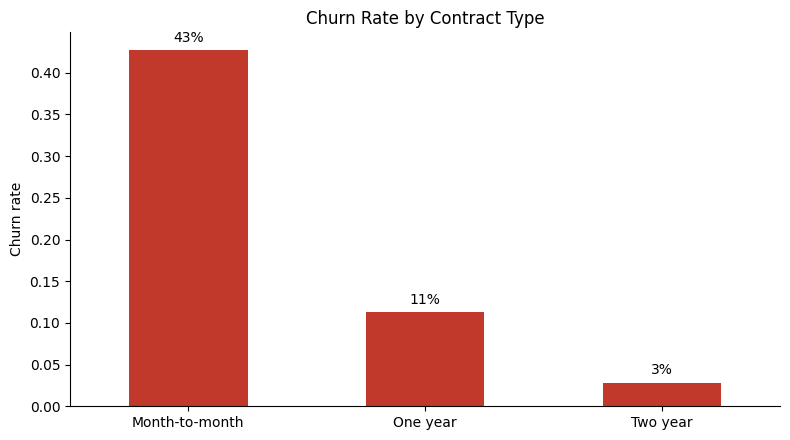

In [15]:
ax = contract_churn["Churn_Rate"].plot(kind="bar", color=ACCENT)
ax.set_title("Churn Rate by Contract Type")
ax.set_ylabel("Churn rate"); ax.set_xlabel("")
for i, v in enumerate(contract_churn["Churn_Rate"]):
    ax.text(i, v + 0.01, f"{v:.0%}", ha="center")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

### 12.2 Churn by tenure group

In [16]:
# Reindex to the natural lifecycle order rather than churn-rate order.
tenure_churn = churn_by("Tenure_Group").reindex(labels)
tenure_churn

,Customers,Churn_Rate
Tenure_Group,,
0-12 Months,2186,0.47
13-24 Months,1024,0.29
25-48 Months,1594,0.20
49+ Months,2239,0.10


### 12.3 Churn by payment method

In [17]:
payment_churn = churn_by("PaymentMethod")
payment_churn

,Customers,Churn_Rate
PaymentMethod,,
Electronic check,2365,0.45
Mailed check,1612,0.19
Bank transfer (automatic),1544,0.17
Credit card (automatic),1522,0.15


### 12.4 Revenue at risk by customer value segment

In [18]:
risk_by_segment = (df.groupby("Customer_Value_Segment", observed=True)
                     .agg(Customers=("Churn_Flag", "size"),
                          Churn_Rate=("Churn_Flag", "mean"),
                          Revenue_At_Risk=("Revenue_At_Risk", "sum"))
                     .sort_values("Revenue_At_Risk", ascending=False))
risk_by_segment

,Customers,Churn_Rate,Revenue_At_Risk
Customer_Value_Segment,,,
High Value,2347,0.34,"76,721.50"
Medium Value,2345,0.30,"49,695.70"
Low Value,2351,0.16,"12,713.65"


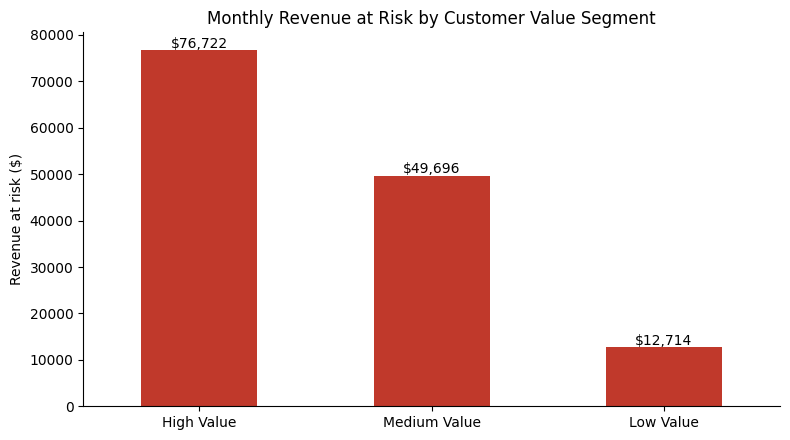

In [19]:
ax = risk_by_segment["Revenue_At_Risk"].plot(kind="bar", color=ACCENT)
ax.set_title("Monthly Revenue at Risk by Customer Value Segment")
ax.set_ylabel("Revenue at risk ($)"); ax.set_xlabel("")
for i, v in enumerate(risk_by_segment["Revenue_At_Risk"]):
    ax.text(i, v + 500, f"${v:,.0f}", ha="center")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

### 12.5 Churn by internet service

In [20]:
internet_churn = churn_by("InternetService")
internet_churn

,Customers,Churn_Rate
InternetService,,
Fiber optic,3096,0.42
DSL,2421,0.19
No,1526,0.07


### 12.6 Churn by customer value segment

In [21]:
segment_churn = churn_by("Customer_Value_Segment")
segment_churn

,Customers,Churn_Rate
Customer_Value_Segment,,
High Value,2347,0.34
Medium Value,2345,0.30
Low Value,2351,0.16


## 13. Export the cleaned dataset

In [22]:
# Persist the cleaned, enriched dataset for SQL and Power BI to consume.
os.makedirs(os.path.dirname(CLEANED_PATH), exist_ok=True)
df.to_csv(CLEANED_PATH, index=False)
print(f"Saved cleaned dataset to {CLEANED_PATH}")
print(f"({df.shape[0]:,} rows, {df.shape[1]} columns)")

Saved cleaned dataset to data/cleaned/telco_churn_cleaned.csv
(7,043 rows, 25 columns)
